# Repeated Cross-Validation Sliding-Window Validation + Signal-Quality Check (All 5 Rats)

**Why this notebook exists:** notebook 009 found that 3 of 5 rats picked their single "best" Odor
Identity window from BEFORE Poke-In, when the odor hasn't even been presented yet, a strong sign that
picking the single maximum out of many tested windows was selecting statistical noise, not real signal,
in at least some cases. This notebook fixes that by using REPEATED cross-validation (5 splits x 5
repeats = 25 scores per window position, instead of 5) and reporting the average curve, which is far
more resistant to any one lucky fold inflating a single window's score. It also adds a basic
signal-quality comparison across rats, to help explain why performance varies so much by rat (Mitt
lowest, Superchris highest in notebook 009).

**Runtime note:** this trains substantially more models than notebook 009 (25 cross-validation folds per
window position instead of 5). Expect this to take several minutes, this is the most compute-heavy
notebook in the project so far, let it run.


In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src.preprocessing import build_labels, get_sampling_rate


## 1. Identify All Sessions

In [2]:
raw_dir = Path('../data/raw')
session_dirs = sorted([p for p in raw_dir.iterdir() if p.is_dir()])
print(f"Found {len(session_dirs)} sessions")


Found 5 sessions


## 2. Settings

**Reduced step size (50ms instead of 25ms) to keep total runtime reasonable**, given repeated
cross-validation multiplies the number of model fits by 5x compared to notebook 009. Span and window
length unchanged.


In [3]:
WINDOW_LENGTH_MS = 250
STEP_MS = 50
SPAN_START_MS = -500
SPAN_END_MS = 1500
N_REPEATS = 5   # each offset gets 5 splits x 5 repeats = 25 cross-validation scores, not just 5

offsets_ms = np.arange(SPAN_START_MS, SPAN_END_MS + 1, STEP_MS)

BANDS = {
    'delta': (1, 4),
    'theta': (4, 12),
    'beta': (12, 30),
    'low_gamma': (30, 80),
    'high_gamma': (80, 150),
}

print(f"{len(offsets_ms)} window positions x {N_REPEATS} repeats x 5 splits = {len(offsets_ms) * N_REPEATS * 5} scores per rat per task")


41 window positions x 5 repeats x 5 splits = 1025 scores per rat per task


## 3. Helper Functions (Windowing Unchanged from Notebooks 008/009)

In [4]:
def extract_window_at_offset(lfp_data, timebin, poke_idx, offset_ms, window_ms, target_samples):
    poke_time = timebin[poke_idx]
    start_time = poke_time + offset_ms / 1000
    end_time = start_time + window_ms / 1000

    start_idx = np.searchsorted(timebin, start_time)
    end_idx = np.searchsorted(timebin, end_time)
    if end_idx - start_idx < 2:
        return None

    raw_window = lfp_data[:, start_idx:end_idx]
    n_channels, n_raw = raw_window.shape
    old_x = np.linspace(0, 1, n_raw)
    new_x = np.linspace(0, 1, target_samples)
    resampled = np.zeros((n_channels, target_samples))
    for ch in range(n_channels):
        resampled[ch] = np.interp(new_x, old_x, raw_window[ch])
    return resampled


def band_power_features(windows, fs, bands):
    n_trials, n_channels, n_samples = windows.shape
    freqs = np.fft.rfftfreq(n_samples, d=1 / fs)
    band_masks = {name: (freqs >= lo) & (freqs < hi) for name, (lo, hi) in bands.items()}
    n_features = n_channels * len(bands)
    X = np.zeros((n_trials, n_features))
    col = 0
    for ch in range(n_channels):
        fft_vals = np.fft.rfft(windows[:, ch, :], axis=1)
        power = np.abs(fft_vals) ** 2
        for band_name, mask in band_masks.items():
            X[:, col] = power[:, mask].sum(axis=1)
            col += 1
    return X


## 4. Repeated-CV Sliding Window Scan, Per Rat

The key change from notebook 009: `RepeatedStratifiedKFold` instead of `StratifiedKFold`, giving 25
scores per window position instead of 5. We record both the mean AND standard deviation across those 25
scores, the standard deviation tells us how much to trust any single offset's mean.


In [5]:
def run_repeated_cv_for_session(session_dir, offsets_ms, window_length_ms, bands, n_repeats):
    session_name = session_dir.name
    bvr = np.load(session_dir / f'{session_name}_bvr.npz', allow_pickle=True)
    bvr_data = bvr['data']
    bvr_keys = bvr['keys'].tolist()
    lfp = np.load(session_dir / f'{session_name}_lfp.npz', allow_pickle=True)
    lfp_data = lfp['data']

    timebin = bvr_data[bvr_keys.index('TimeBin')]
    avg_fs = get_sampling_rate(bvr_data, bvr_keys)
    labels = build_labels(bvr_data, bvr_keys)
    target_samples = int(round(window_length_ms / 1000 * avg_fs))

    min_before = abs(offsets_ms[0]) / 1000
    max_after = (offsets_ms[-1] + window_length_ms) / 1000

    valid_trial_idx = []
    for t in labels['trial_idx']:
        pt = timebin[t]
        if pt - min_before < timebin[0] or pt + max_after > timebin[-1]:
            continue
        valid_trial_idx.append(t)
    valid_trial_idx = np.array(valid_trial_idx)
    valid_mask = np.isin(labels['trial_idx'], valid_trial_idx)
    inseq_outseq = labels['inseq_outseq'][valid_mask]
    odor_id = labels['odor_id'][valid_mask]

    inseq_mean, inseq_std, odor_mean, odor_std = [], [], [], []
    rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=n_repeats, random_state=42)

    for offset in offsets_ms:
        windows = []
        for t in valid_trial_idx:
            w = extract_window_at_offset(lfp_data, timebin, t, offset, window_length_ms, target_samples)
            windows.append(w)
        windows = np.stack(windows, axis=0)
        X = np.log1p(band_power_features(windows, avg_fs, bands))

        pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
        inseq_scores = cross_val_score(pipe, X, inseq_outseq, cv=rcv, scoring='balanced_accuracy')
        inseq_mean.append(inseq_scores.mean())
        inseq_std.append(inseq_scores.std())

        inseq_mask_local = (inseq_outseq == 1)
        X_odor = X[inseq_mask_local]
        y_odor = odor_id[inseq_mask_local]
        rcv_odor = RepeatedStratifiedKFold(n_splits=5, n_repeats=n_repeats, random_state=42)
        odor_scores = cross_val_score(pipe, X_odor, y_odor, cv=rcv_odor, scoring='balanced_accuracy')
        odor_mean.append(odor_scores.mean())
        odor_std.append(odor_scores.std())

    return {
        'session': session_name,
        'n_trials': len(valid_trial_idx),
        'inseq_mean': np.array(inseq_mean),
        'inseq_std': np.array(inseq_std),
        'odor_mean': np.array(odor_mean),
        'odor_std': np.array(odor_std),
    }


all_results = {}
for session_dir in session_dirs:
    print(f"Running {session_dir.name}...")
    result = run_repeated_cv_for_session(session_dir, offsets_ms, WINDOW_LENGTH_MS, BANDS, N_REPEATS)
    all_results[session_dir.name] = result
    print(f"  done, InSeq/OutSeq best (mean)={result['inseq_mean'].max():.3f}, "
          f"Odor best (mean)={result['odor_mean'].max():.3f}")

print("\nAll rats complete.")


Running 080718_mitt...
  done, InSeq/OutSeq best (mean)=0.701, Odor best (mean)=0.381
Running 081106_barat...
  done, InSeq/OutSeq best (mean)=0.731, Odor best (mean)=0.433
Running 090212_stella...
  done, InSeq/OutSeq best (mean)=0.798, Odor best (mean)=0.474
Running 090212_superchris...
  done, InSeq/OutSeq best (mean)=0.887, Odor best (mean)=0.431
Running 090420_buchanan...
  done, InSeq/OutSeq best (mean)=0.707, Odor best (mean)=0.464

All rats complete.


## 5. Faceted Plots, One Panel Per Rat

Small multiples instead of overlaid lines, each rat gets its own panel, showing the mean curve with a
shaded band for +/- 1 standard deviation across the 25 repeated-CV scores. This directly shows how much
to trust any peak, a peak sitting well outside its own shaded uncertainty band is far more believable
than one that's barely poking above it.


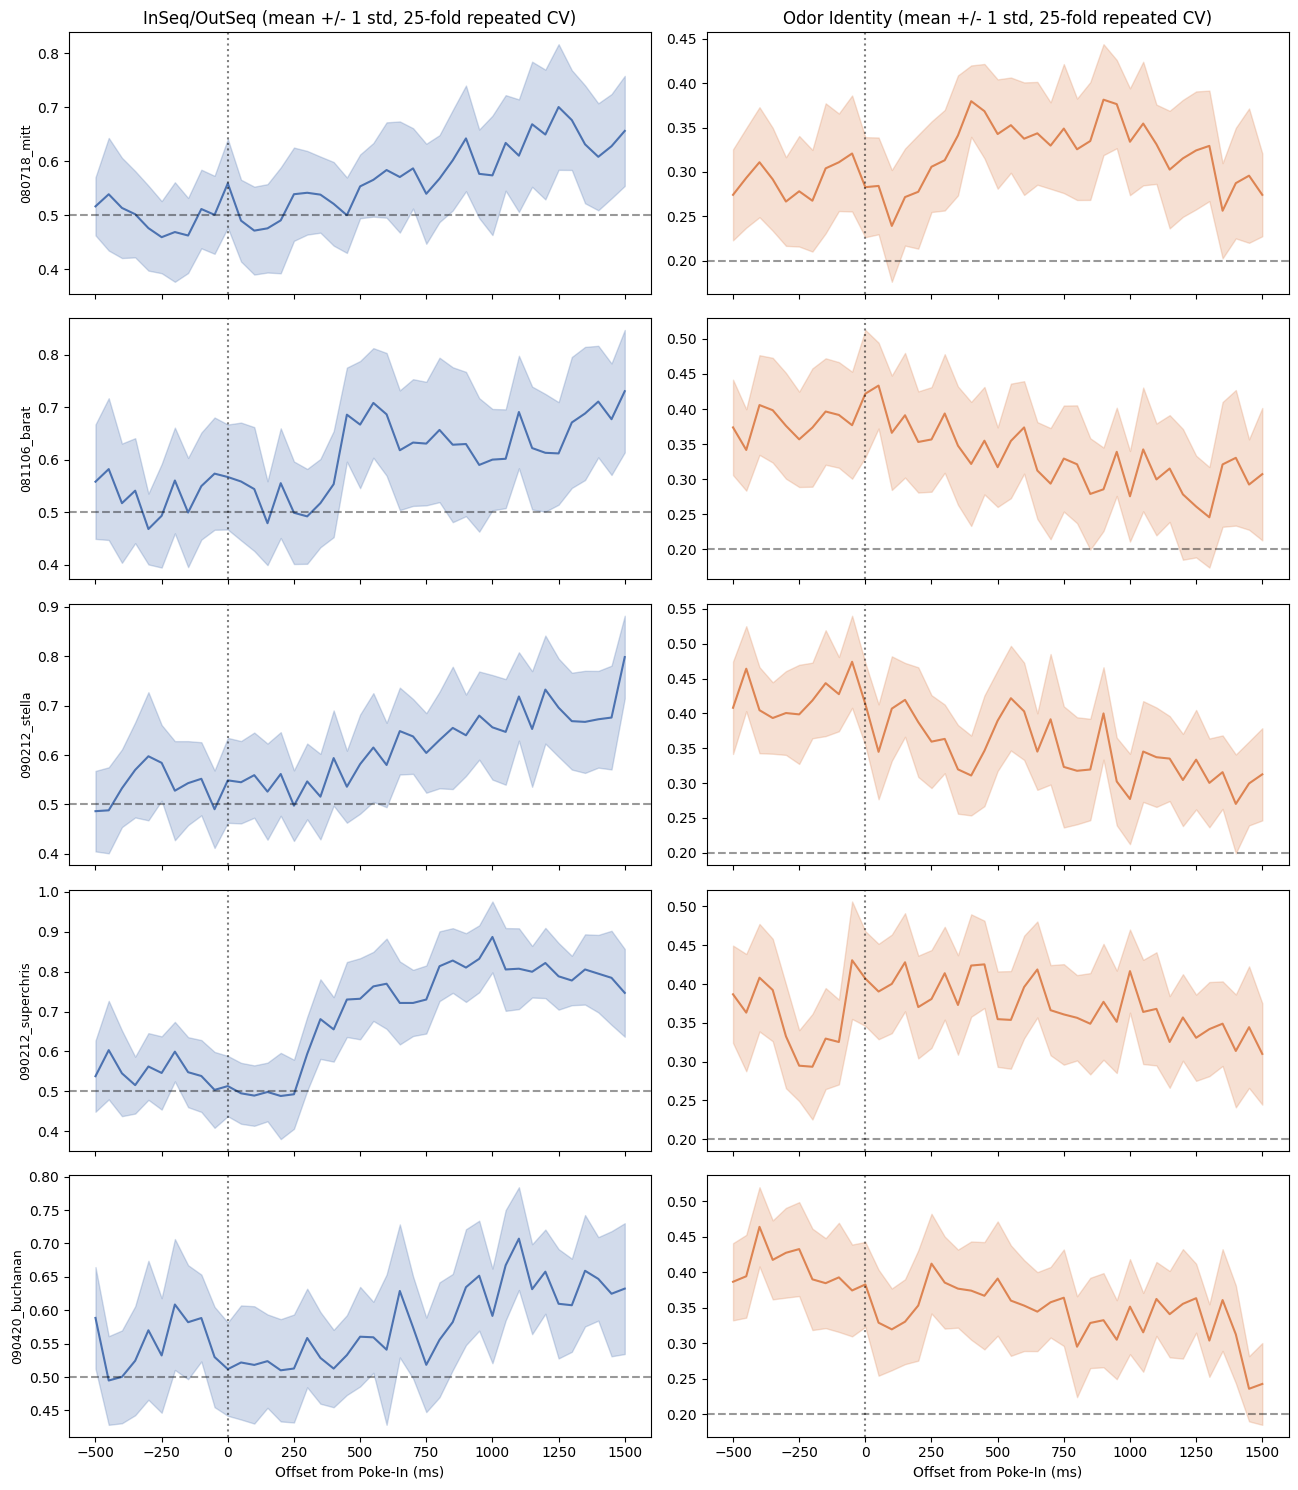

In [6]:
session_names = list(all_results.keys())
n_rats = len(session_names)

fig, axes = plt.subplots(n_rats, 2, figsize=(13, 3 * n_rats), sharex=True)

for row, session_name in enumerate(session_names):
    r = all_results[session_name]

    ax = axes[row, 0]
    ax.plot(offsets_ms, r['inseq_mean'], color='#4C72B0')
    ax.fill_between(offsets_ms, r['inseq_mean'] - r['inseq_std'], r['inseq_mean'] + r['inseq_std'],
                     color='#4C72B0', alpha=0.25)
    ax.axhline(0.5, color='black', linestyle='--', alpha=0.4)
    ax.axvline(0, color='black', linestyle=':', alpha=0.5)
    ax.set_ylabel(session_name, fontsize=9)
    if row == 0:
        ax.set_title('InSeq/OutSeq (mean +/- 1 std, 25-fold repeated CV)')

    ax = axes[row, 1]
    ax.plot(offsets_ms, r['odor_mean'], color='#DD8452')
    ax.fill_between(offsets_ms, r['odor_mean'] - r['odor_std'], r['odor_mean'] + r['odor_std'],
                     color='#DD8452', alpha=0.25)
    ax.axhline(0.2, color='black', linestyle='--', alpha=0.4)
    ax.axvline(0, color='black', linestyle=':', alpha=0.5)
    if row == 0:
        ax.set_title('Odor Identity (mean +/- 1 std, 25-fold repeated CV)')

axes[-1, 0].set_xlabel('Offset from Poke-In (ms)')
axes[-1, 1].set_xlabel('Offset from Poke-In (ms)')
plt.tight_layout()
plt.show()


## 6. Validated Peak Comparison: Single-Run (Notebook 009) vs. Repeated-CV (This Notebook)

The most important check: did the implausible pre-Poke-In "wins" for Odor Identity survive averaging
over 25 folds instead of 5? If repeated-CV pushes the best offset to a post-Poke-In position, that
confirms the original single-run results were noise-driven.


In [7]:
prior_results = {
    '080718_mitt':      {'inseq_offset': 1475, 'inseq_acc': 0.6952, 'odor_offset': 1025, 'odor_acc': 0.4279},
    '081106_barat':     {'inseq_offset': 1475, 'inseq_acc': 0.8098, 'odor_offset': -275, 'odor_acc': 0.4609},
    '090212_stella':    {'inseq_offset': 1500, 'inseq_acc': 0.8065, 'odor_offset': -425, 'odor_acc': 0.4897},
    '090212_superchris':{'inseq_offset': 1000, 'inseq_acc': 0.8976, 'odor_offset': 450,  'odor_acc': 0.4610},
    '090420_buchanan':  {'inseq_offset': 1125, 'inseq_acc': 0.7126, 'odor_offset': -400, 'odor_acc': 0.4665},
}

print(f"{'Rat':20s} {'NB009 InSeq':12s} {'NB010 InSeq':12s} {'NB009 Odor@':12s} {'NB010 Odor@':12s}")
print("-" * 75)

validated_summary = []
for session_name in session_names:
    r = all_results[session_name]
    inseq_best_idx = r['inseq_mean'].argmax()
    odor_best_idx = r['odor_mean'].argmax()

    prior = prior_results[session_name]
    print(f"{session_name:20s} {prior['inseq_acc']:<12.3f} {r['inseq_mean'][inseq_best_idx]:<12.3f} "
          f"{prior['odor_offset']:<12d} {offsets_ms[odor_best_idx]:<12d}")

    validated_summary.append({
        'session': session_name,
        'inseq_validated_best_acc': round(float(r['inseq_mean'][inseq_best_idx]), 4),
        'inseq_validated_best_offset_ms': int(offsets_ms[inseq_best_idx]),
        'inseq_validated_std_at_best': round(float(r['inseq_std'][inseq_best_idx]), 4),
        'odor_validated_best_acc': round(float(r['odor_mean'][odor_best_idx]), 4),
        'odor_validated_best_offset_ms': int(offsets_ms[odor_best_idx]),
        'odor_validated_std_at_best': round(float(r['odor_std'][odor_best_idx]), 4),
        'odor_offset_now_post_poke': bool(offsets_ms[odor_best_idx] >= 0),
    })

n_now_post_poke = sum(row['odor_offset_now_post_poke'] for row in validated_summary)
print(f"\nRats where validated Odor Identity best offset is now post-Poke-In (>= 0ms): {n_now_post_poke} of {len(validated_summary)}")


Rat                  NB009 InSeq  NB010 InSeq  NB009 Odor@  NB010 Odor@ 
---------------------------------------------------------------------------
080718_mitt          0.695        0.701        1025         900         
081106_barat         0.810        0.731        -275         50          
090212_stella        0.806        0.798        -425         -50         
090212_superchris    0.898        0.887        450          -50         
090420_buchanan      0.713        0.707        -400         -400        

Rats where validated Odor Identity best offset is now post-Poke-In (>= 0ms): 2 of 5


## 7. Signal-Quality Comparison Across Rats

A simple, direct check on whether raw signal characteristics differ meaningfully by rat, which could
help explain why InSeq/OutSeq decoding accuracy varies so much (Mitt weakest, Superchris strongest in
notebook 009). We compute RMS (root-mean-square) amplitude of the raw LFP signal, averaged across all
channels and the whole recording, for each rat, a simple proxy for overall signal strength.


080718_mitt          mean RMS amplitude: 0.1607   (std across channels: 0.0246)
081106_barat         mean RMS amplitude: 0.1291   (std across channels: 0.0460)
090212_stella        mean RMS amplitude: 0.1440   (std across channels: 0.0163)
090212_superchris    mean RMS amplitude: 0.2687   (std across channels: 0.0928)
090420_buchanan      mean RMS amplitude: 0.1455   (std across channels: 0.0243)


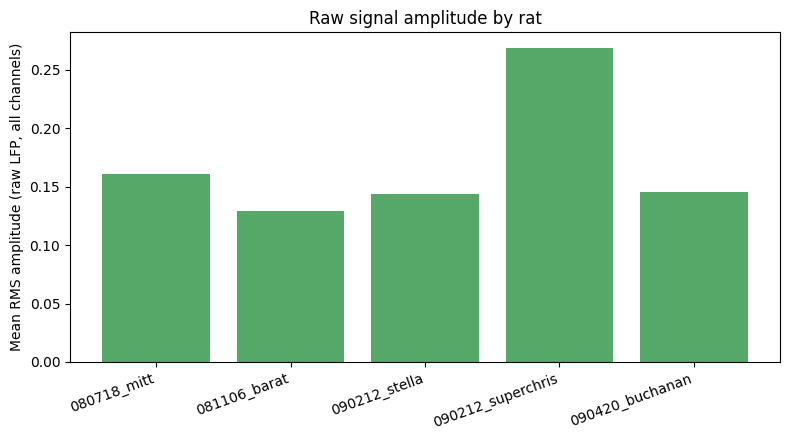


Compare this ordering against notebook 009's InSeq/OutSeq peak accuracy ordering
(Superchris highest, Mitt lowest) to check whether raw signal amplitude tracks with
decoding performance, or whether the performance difference comes from somewhere else
(e.g. electrode placement quality, behavioral consistency, not raw amplitude).


In [8]:
signal_quality = []
for session_dir in session_dirs:
    session_name = session_dir.name
    lfp = np.load(session_dir / f'{session_name}_lfp.npz', allow_pickle=True)
    lfp_data = lfp['data']

    rms_per_channel = np.sqrt(np.mean(lfp_data ** 2, axis=1))
    mean_rms = rms_per_channel.mean()
    std_rms_across_channels = rms_per_channel.std()

    signal_quality.append({
        'session': session_name,
        'mean_rms_amplitude': round(float(mean_rms), 4),
        'std_rms_across_channels': round(float(std_rms_across_channels), 4),
    })
    print(f"{session_name:20s} mean RMS amplitude: {mean_rms:.4f}   (std across channels: {std_rms_across_channels:.4f})")

fig, ax = plt.subplots(figsize=(8, 4.5))
names = [s['session'] for s in signal_quality]
rms_vals = [s['mean_rms_amplitude'] for s in signal_quality]
ax.bar(names, rms_vals, color='#55A868')
ax.set_ylabel('Mean RMS amplitude (raw LFP, all channels)')
ax.set_title('Raw signal amplitude by rat')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print("\nCompare this ordering against notebook 009's InSeq/OutSeq peak accuracy ordering")
print("(Superchris highest, Mitt lowest) to check whether raw signal amplitude tracks with")
print("decoding performance, or whether the performance difference comes from somewhere else")
print("(e.g. electrode placement quality, behavioral consistency, not raw amplitude).")


## 8. Text-Only Results Export


In [9]:
import json as _json
import os

results_summary = {
    "purpose": "Repeated-CV validation of notebook 009's sliding-window results, plus signal-quality comparison",
    "window_length_ms": WINDOW_LENGTH_MS,
    "step_ms": STEP_MS,
    "span_ms": [int(SPAN_START_MS), int(SPAN_END_MS)],
    "n_repeats": N_REPEATS,
    "bands": {name: list(rng) for name, rng in BANDS.items()},
    "validated_per_rat_summary": validated_summary,
    "n_rats_odor_offset_now_post_poke": n_now_post_poke,
    "n_rats_total": len(validated_summary),
    "signal_quality_by_rat": signal_quality,
}

print(_json.dumps(results_summary, indent=2))

os.makedirs('../outputs/logs', exist_ok=True)
with open('../outputs/logs/notebook010_results.json', 'w') as f:
    _json.dump(results_summary, f, indent=2)
print("\nSaved to outputs/logs/notebook010_results.json")


{
  "purpose": "Repeated-CV validation of notebook 009's sliding-window results, plus signal-quality comparison",
  "window_length_ms": 250,
  "step_ms": 50,
  "span_ms": [
    -500,
    1500
  ],
  "n_repeats": 5,
  "bands": {
    "delta": [
      1,
      4
    ],
    "theta": [
      4,
      12
    ],
    "beta": [
      12,
      30
    ],
    "low_gamma": [
      30,
      80
    ],
    "high_gamma": [
      80,
      150
    ]
  },
  "validated_per_rat_summary": [
    {
      "session": "080718_mitt",
      "inseq_validated_best_acc": 0.7005,
      "inseq_validated_best_offset_ms": 1250,
      "inseq_validated_std_at_best": 0.1166,
      "odor_validated_best_acc": 0.3814,
      "odor_validated_best_offset_ms": 900,
      "odor_validated_std_at_best": 0.0625,
      "odor_offset_now_post_poke": true
    },
    {
      "session": "081106_barat",
      "inseq_validated_best_acc": 0.7307,
      "inseq_validated_best_offset_ms": 1500,
      "inseq_validated_std_at_best": 0.1168,
     

## 9. Written Summary Report

**Objective**

Determine whether notebook 009's per-rat "best window" findings (especially the implausible
pre-Poke-In peaks for Odor Identity in 3 of 5 rats) reflect real signal or search noise from picking a
single maximum across 81 tested window positions, by re-evaluating with repeated cross-validation
(25 scores per position instead of 5). Also check whether raw signal quality differs by rat in a way
that could explain the InSeq/OutSeq performance spread found in notebook 009.

**Method**

Same sliding-window approach as notebooks 008/009, but using `RepeatedStratifiedKFold` (5 splits x 5
repeats = 25 scores per window position) instead of a single 5-fold split, and a coarser 50ms step (vs.
25ms) to keep total runtime manageable. Raw LFP RMS amplitude, averaged across channels and the full
recording, computed per rat as a simple signal-quality proxy.

**Results**

*(Fill in after running Sections 6-7 above.)* How many rats now show a post-Poke-In (>= 0ms) best Odor
Identity offset, versus the 2 of 5 that were post-Poke-In in notebook 009? Do the validated InSeq/OutSeq
peak accuracies (Section 6) still show Mitt lowest and Superchris highest, or does the ranking change
once evaluated more robustly? Does raw RMS amplitude (Section 7) track with the InSeq/OutSeq performance
ranking?

**Interpretation**

*(Fill in after review.)* If most/all pre-Poke-In "wins" disappear under repeated CV, that confirms the
original notebook 009 single-run peaks were substantially inflated by search noise, and the validated
(lower, more stable) numbers here are the ones to trust and report. If the per-rat performance ranking
holds up under repeated CV, that strengthens the case that rats genuinely differ, worth investigating
further (signal quality, electrode placement, behavioral consistency) rather than treating it as noise.

**Next Steps**

1. Adopt the validated (repeated-CV) window and accuracy numbers from this notebook as the ones to
   report and build on going forward, not the single-run notebook 009 numbers.
2. If per-rat differences are confirmed real, decide whether to build a shared pooled model anyway
   (accepting some inefficiency for weaker rats) or pursue rat-specific windows.
3. Run a permutation test on the validated best result to confirm it's statistically distinguishable
   from chance before presenting Sep 1-2.
4. Move to the actual multi-rat pooled training pipeline (session-based train/test split) using the
   validated window choice.
